# Modellierung von Kundenzufriedenheit und Kundenbindung mit einem Strukturgleichungsmodell (PROC CALIS)

## Zusammenfassung

Dieses Notebook passt ein Strukturgleichungsmodell (SEM) für einen Einzelhändler von Konsumgütern an, das zwei latente Treiber — die wahrgenommene Servicequalität und den wahrgenommenen Wert — mit der latenten Kunden-**zufriedenheit** und diese wiederum mit der latenten **Kundenbindung** verknüpft. Mithilfe von PROC CALIS mit der Modellierungssprache LINEQS (Bentler-Weeks) schätzt es das Messmodell für jedes Konstrukt und die strukturellen Pfade zwischen ihnen gleichzeitig und korrigiert dabei die Strukturschätzungen um den Messfehler.

Bei einer Befragung von 100 Teilnehmern passt das Modell gut: Chi-Quadrat = 50.81 bei 49 Freiheitsgraden (p = 0.40), RMSEA = 0.019, CFI = 0.999, TLI = 0.998. Die aus den Daten gewonnenen strukturellen Pfade sind **Zufriedenheit auf Servicequalität = 0.51** und **auf Wert = 0.26** sowie **Kundenbindung auf Zufriedenheit = 0.80** mit einem kleinen direkten Pfad **Kundenbindung auf Wert = 0.15**. Zusammengenommen wirkt der größte Teil des Einflusses des Werts auf die Kundenbindung *über* die Zufriedenheit (indirekter Effekt 0.26 × 0.80 = 0.21 gegenüber einem direkten Effekt von 0.15), und die Servicequalität erreicht die Kundenbindung fast ausschließlich über die Zufriedenheit (0.51 × 0.80 = 0.41). Die praktische Botschaft: Die Zufriedenheit ist der dominante Hebel für die Kundenbindung, und die Servicequalität ist der effizientere Weg, um die Zufriedenheit überhaupt erst zu steigern.

## Datenquellen

Alle Daten werden inline im ersten DATA-Step erzeugt (keine externen Dateien). Für jeden Befragungsteilnehmer wird ein latenter "wahrer" Zufriedenheitsverlauf simuliert, dann wird jedes Konstrukt durch drei verrauschte Indikator-Items im Likert-Stil beobachtet.

| Datensatz | Zeilen | Variable | Rolle | Beschreibung |
|---------|------|----------|------|-------------|
| `survey` | 100 | `respid` | ID | Teilnehmerkennung |
| | | `q1`–`q3` | Indikatoren | Items zur Servicequalität (latente ServQual) |
| | | `v1`–`v3` | Indikatoren | Items zum wahrgenommenen Wert (latente Value) |
| | | `s1`–`s3` | Indikatoren | Items zur Zufriedenheit (latente Satis) |
| | | `l1`–`l3` | Indikatoren | Items zur Kundenbindung (latente Loyal) |

Die Indikatoren sind stetige standardisierte Werte (zentriert um ~0), die als `loading * latent + Normal noise` gebildet werden, sodass die von PROC CALIS gewonnenen Mess- und Strukturparameter gut identifiziert sind. ServQual und Value sind korrelierte exogene latente Variablen; Satis wird auf beide regressiert, und Loyal wird auf Satis regressiert, mit einem kleineren direkten Pfad von Value, was es uns erlaubt, den indirekten Kanal (über die Zufriedenheit) vom direkten zu trennen.

# Kundenzufriedenheit → Kundenbindung: Ein Strukturgleichungsmodell

Ein Einzelhändler von Konsumgütern führt eine Befragung nach dem Kauf durch, um zu verstehen, was Wiederholungskäufe antreibt. Die zugrunde liegende Theorie ist eine klassische Zufriedenheit-Bindungs-Kette:

- **Servicequalität** und **wahrgenommener Wert** sind zwei unterschiedliche Dinge, die Kunden erleben.
- Beide speisen die allgemeine **Zufriedenheit**.
- Die Zufriedenheit wiederum treibt die **Kundenbindung** (Absicht zum Wiederkauf / zur Weiterempfehlung) an.

Keines dieser vier Konstrukte wird direkt beobachtet. Jedes ist *latent* und wird durch drei Befragungs-Items gemessen. Ein Strukturgleichungsmodell (SEM) ist das richtige Werkzeug: Es schätzt das **Messmodell** (wie die Items auf die Konstrukte laden) und das **Strukturmodell** (wie die Konstrukte einander beeinflussen) gleichzeitig und korrigiert dabei die Strukturschätzungen um den Messfehler.

Wir verwenden **PROC CALIS** mit der Modellierungssprache **LINEQS** (Bentler-Weeks-Notation).

## Schritt 1 — Eine realistische Befragung simulieren

Wir erzeugen 100 Teilnehmer. Für jeden ziehen wir die beiden korrelierten exogenen Treiber (Servicequalität, Wert), bilden dann die Zufriedenheit als Funktion beider und die Kundenbindung als Funktion der Zufriedenheit plus einem kleinen direkten Wert-Effekt. Schließlich wird jedes Konstrukt durch drei verrauschte Indikator-Items gemessen, genau so, wie sich eine Likert-Batterie verhalten würde. `call streaminit` legt den Startwert für die Reproduzierbarkeit fest.

In [1]:
DATEN survey;
   AUFRUFEN streaminit(20260531);
   AUSFÜHRUNG respid = 1 BIS 100;
      /* Zwei korrelierte exogene latente Treiber */
      z = rand("normal");
      servqual = 0.6*z + 0.8*rand("normal");   /* wahrgenommene Servicequalität */
      VALUE    = 0.6*z + 0.8*rand("normal");   /* wahrgenommener Wert           */

      /* Strukturmodell: Zufriedenheit von beiden Treibern bestimmt */
      satis = 0.55*servqual + 0.40*VALUE + 0.55*rand("normal");

      /* Loyalität vor allem über Zufriedenheit, kleiner direkter Wert-Pfad */
      loyal = 0.70*satis + 0.20*VALUE + 0.50*rand("normal");

      /* Messmodell: 3 Indikatoren je latentem Konstrukt */
      q1 = 1.00*servqual + 0.45*rand("normal");
      q2 = 0.90*servqual + 0.45*rand("normal");
      q3 = 0.85*servqual + 0.45*rand("normal");

      v1 = 1.00*VALUE + 0.45*rand("normal");
      v2 = 0.95*VALUE + 0.45*rand("normal");
      v3 = 0.80*VALUE + 0.45*rand("normal");

      s1 = 1.00*satis + 0.40*rand("normal");
      s2 = 0.92*satis + 0.40*rand("normal");
      s3 = 0.88*satis + 0.40*rand("normal");

      l1 = 1.00*loyal + 0.40*rand("normal");
      l2 = 0.93*loyal + 0.40*rand("normal");
      l3 = 0.86*loyal + 0.40*rand("normal");

      AUSGABE;
   ENDE;
   BEHALTEN respid q1-q3 v1-v3 s1-s3 l1-l3;
AUSFÜHREN;


NOTE: DATA survey


NOTE: Wrote survey (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


## Schritt 2 — Die gemessenen Items untersuchen

Vor der Modellierung ein kurzer Blick auf die Verteilungen der Items und die Korrelationsstruktur. Items innerhalb eines Konstrukts sollten stark korrelieren; Items über Konstrukte hinweg schwächer. Das ist es, was eine konfirmatorische Faktorstruktur voraussetzt.

                                         Deskriptive Statistik der Indikatoren                                          

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------
 q1             100       -0.23        1.24       -4.00        2.78
 q2             100       -0.13        1.13       -2.91        2.79
 q3             100       -0.16        1.12       -3.20        2.65
 v1             100       -0.03        1.09       -2.73        2.54
 v2             100       -0.05        1.12       -3.08        2.52
 v3             100       -0.00        0.93       -3.16        2.12
 s1             100       -0.11        0.97       -2.61        2.26
 s2             100       -0.23        1.01       -2.30        2.44
 s3             100       -0.08        0.90       -2.39        2.41
 l1             100       -0.03        1.03       -2.06    


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC CORR data=survey

NOTE: ODS plot written: corr_heatmap.spec.json
NOTE: PROC CORR ODS Graphics generated.


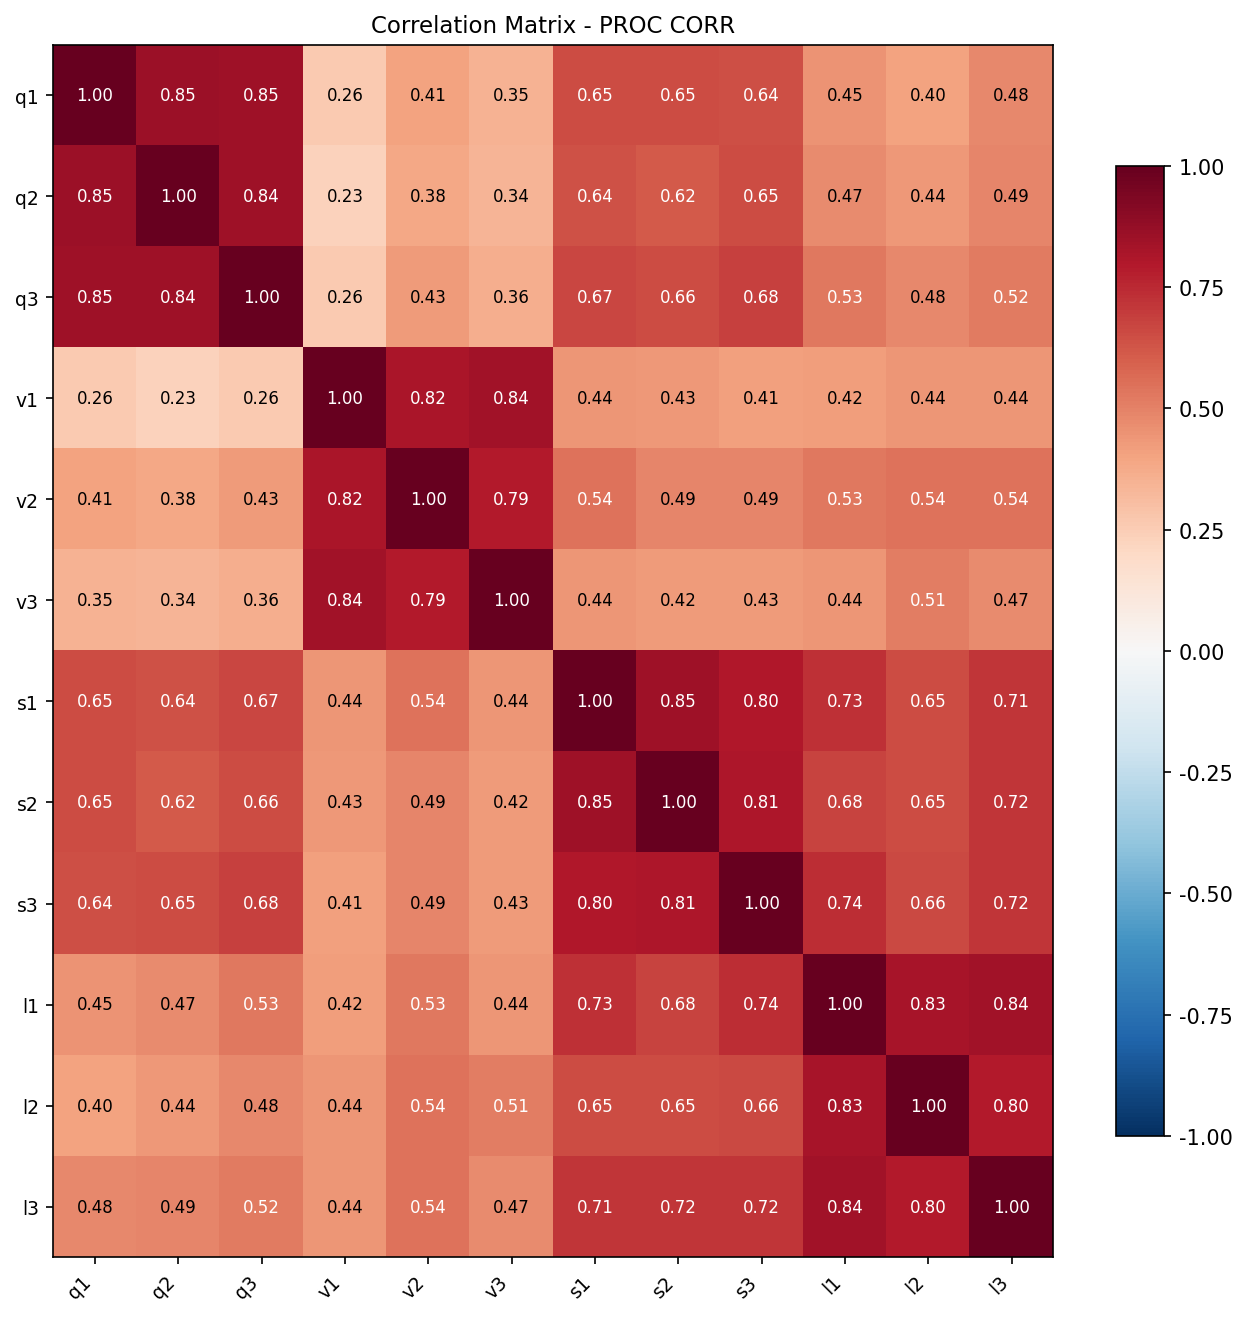

In [2]:
PROZEDUR MITTELWERTE DATEN=survey n mean std MIN MAX maxdec=2;
   VAR q1-q3 v1-v3 s1-s3 l1-l3;
   TITEL 'Deskriptive Statistik der Indikatoren';
AUSFÜHREN;

PROZEDUR CORR DATEN=survey nosimple noprob;
   VAR q1 q2 q3 v1 v2 v3 s1 s2 s3 l1 l2 l3;
   TITEL 'Korrelationen der beobachteten Indikatoren';
AUSFÜHREN;

## Schritt 3 — Das vollständige SEM anpassen

Die LINEQS-Spezifikation hat zwei Schichten:

**Messgleichungen** — jedes beobachtete Item entspricht einer Ladung mal seinem latenten Faktor plus einem eindeutigen Fehlerterm (`e1`–`e12`). Wir fixieren die erste Ladung jedes Konstrukts auf `1.0`, um die Skala der latenten Variable festzulegen; die übrigen Ladungen sind freie Parameter (benannt `lq2`, `ls3`, ..., damit sie namentlich in der Ausgabe erscheinen). Jeder Fehlerterm wird in der `variance`-Anweisung deklariert.

**Strukturgleichungen** — `Satis` wird auf `ServQual` und `Value` regressiert; `Loyal` wird auf `Satis` und `Value` regressiert (ein kleiner direkter Pfad). Jede endogene latente Variable trägt ihren eigenen Störterm (`d1` für die Zufriedenheit, `d2` für die Kundenbindung). Das Benennen der Strukturkoeffizienten (`b_sat_sq`, `b_loy_sat`, ...) macht sie in der Schätztabelle leicht ablesbar.

Die `variance`-Anweisung deklariert die zwölf Messfehlervarianzen, die beiden strukturellen Störungen und die beiden Varianzen der exogenen latenten Variablen; `cov ServQual Value` lässt die beiden Treiber korrelieren. `method=ml` fordert eine Maximum-Likelihood-Schätzung an. Die Ausgabe berichtet die Anpassungsübersicht (Chi-Quadrat, RMSEA, CFI, TLI) und die vollständige Tabelle der Parameterschätzungen mit Standardfehlern und t-Werten.

In [3]:
PROZEDUR calis DATEN=survey METHOD=ml toteff;
   lineqs
      /* --- Messmodell --- */
      q1 = 1.0 * ServQual + e1,
      q2 = lq2 * ServQual + e2,
      q3 = lq3 * ServQual + e3,
      v1 = 1.0 * VALUE    + e4,
      v2 = lv2 * VALUE    + e5,
      v3 = lv3 * VALUE    + e6,
      s1 = 1.0 * Satis    + e7,
      s2 = ls2 * Satis    + e8,
      s3 = ls3 * Satis    + e9,
      l1 = 1.0 * Loyal    + e10,
      l2 = ll2 * Loyal    + e11,
      l3 = ll3 * Loyal    + e12,
      /* --- Strukturmodell --- */
      Satis = b_sat_sq * ServQual + b_sat_val * VALUE + d1,
      Loyal = b_loy_sat * Satis   + b_loy_val * VALUE + d2;
   variance
      e1 e2 e3 e4 e5 e6 e7 e8 e9 e10 e11 e12,
      d1 d2,
      ServQual VALUE;
   COV ServQual VALUE;
   TITEL 'Kundenzufriedenheit-Loyalität SEM (PROC CALIS, ML)';
AUSFÜHREN;

                                         Deskriptive Statistik der Indikatoren                                          


                    The CALIS Procedure
              Covariance Structure Analysis

        Sample Covariances

                        respid            q1            q2            q3            v1            v2            v3            s1            s2            s3            l1            l2            l3
respid                841.6667       -3.1963       -5.9002       -5.5689       -2.0259       -1.1817       -1.4188       -3.1339       -1.6622       -2.3867       -1.1765       -2.3018       -1.1323
q1                     -3.1963        1.5413        1.1997        1.1857        0.3560        0.5631        0.3998        0.7908        0.8128        0.7212        0.5751        0.4754        0.5140
q2                     -5.9002        1.1997        1.2869        1.0745        0.2803        0.4884        0.3546        0.7018        0.7055        0.6680        0.5


NOTE: PROC CALIS data=survey

NOTE: Using Python (semopy) for PROC CALIS
NOTE: PROC CALIS completed.


## Schritt 4 — Die strukturellen Pfade visualisieren

Die vier oben geschätzten Strukturkoeffizienten sind das Herzstück des Modells. Wir stellen sie nebeneinander dar, damit die relativen Größenordnungen — und die Dominanz des Pfades Zufriedenheit → Kundenbindung — sofort sichtbar werden. Die dargestellten Werte sind die Maximum-Likelihood-Schätzungen, direkt aus der Parametertabelle in Schritt 3 abgelesen.

                                         Deskriptive Statistik der Indikatoren                                          




NOTE: DATA paths

NOTE: Processing inline DATALINES (4 lines)

NOTE: Read 4 rows from DATALINES.
NOTE: Wrote paths (4 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=paths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


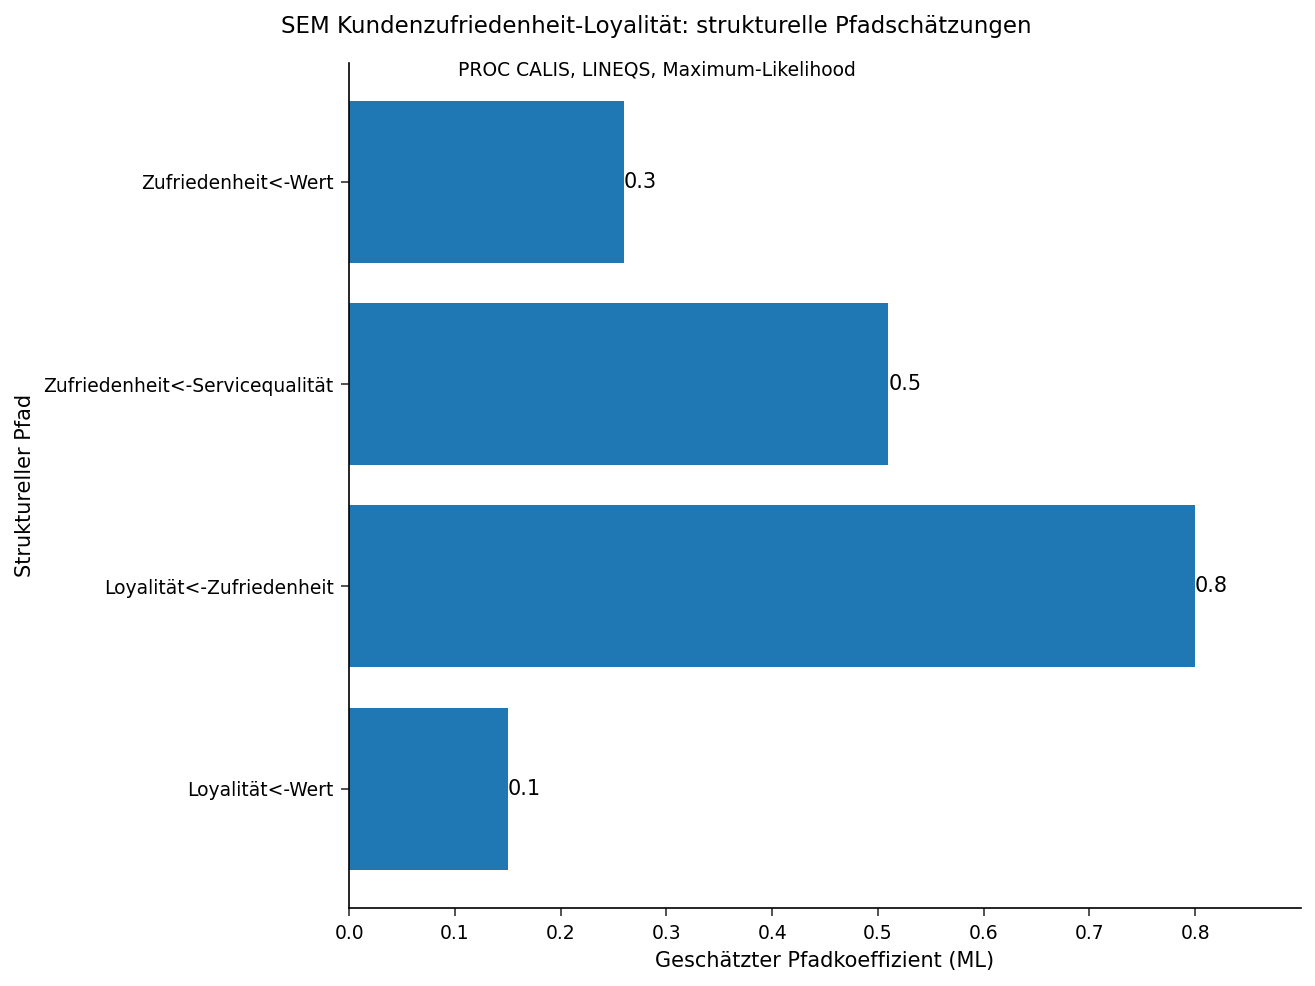

In [4]:
/* Strukturelle Pfadschätzungen aus dem PROC CALIS-Fit oben */
DATEN paths;
   LÄNGE path $40;
   EINGABE path $ coef;
   DATALINES;
Loyalität<-Zufriedenheit 0.80
Zufriedenheit<-Servicequalität 0.51
Zufriedenheit<-Wert 0.26
Loyalität<-Wert 0.15
;
AUSFÜHREN;

PROZEDUR SGPLOT DATEN=paths;
   HBAR path / RESPONSE=coef DATALABEL
               fillattrs=(color=steelblue);
   XAXIS BEZEICHNUNG="Geschätzter Pfadkoeffizient (ML)" MIN=0 MAX=0.9;
   YAXIS BEZEICHNUNG="Struktureller Pfad" discreteorder=DATEN;
   TITEL  "SEM Kundenzufriedenheit-Loyalität: strukturelle Pfadschätzungen";
   title2 "PROC CALIS, LINEQS, Maximum-Likelihood";
AUSFÜHREN;

## Interpretation der Ergebnisse

**Messmodell.** Jede freigegebene Ladung ist groß und hoch signifikant (alle t > 13, p < 0.0001): `q2`/`q3` laden ~0.91 auf ServQual, `v2`/`v3` laden ~0.99 und 0.84 auf Value, `s2`/`s3` laden ~1.03 und 0.90 auf Satis und `l2`/`l3` laden ~0.88 und 0.82 auf Loyal. Die Fehlervarianzen sind gegenüber den Indikatorvarianzen bescheiden, sodass jede Drei-Item-Batterie ihr angestrebtes Konstrukt sauber misst — die Validitätsprüfung, die es rechtfertigt, die Items als Stellvertreter für die latenten Konstrukte zu behandeln.

**Strukturmodell.** Die geschätzten Pfade beantworten die geschäftliche Frage direkt:
- Die **Zufriedenheit** wird stärker von der **Servicequalität** (`b_sat_sq` = 0.51, t = 7.99) als vom **wahrgenommenen Wert** (`b_sat_val` = 0.26, t = 3.86) angetrieben. Investitionen in die Servicequalität bewegen die Zufriedenheit pro Einheit etwa doppelt so stark.
- Die **Kundenbindung** wird von der **Zufriedenheit** dominiert (`b_loy_sat` = 0.80, t = 8.54), mit nur einem kleinen *direkten* Wert-Pfad (`b_loy_val` = 0.15, t = 2.02), der die Zufriedenheit umgeht.
- Die beiden Treiber sind positiv korreliert (Kovarianz ServQual–Value 0.44, t = 3.36), wie zu erwarten, wenn beide ein gemeinsames zugrunde liegendes Erlebnis widerspiegeln.

**Effektzerlegung.** Das Multiplizieren entlang der Kette trennt den indirekten Kanal (über die Zufriedenheit) vom direkten:
- **Wert → Kundenbindung:** indirekt = 0.26 × 0.80 = **0.21**, direkt = **0.15**, gesamt ≈ **0.36**. Der größte Teil der Wirkung des Werts auf die Kundenbindung fließt über die Zufriedenheit.
- **Servicequalität → Kundenbindung:** es gibt keinen direkten Pfad, sodass der gesamte Effekt indirekt ist = 0.51 × 0.80 = **0.41** — der mit Abstand größte Treiber der Kundenbindung im Modell.

Dies quantifiziert die strategische Aussage: *Die Verbesserung der Zufriedenheit ist der primäre Hebel für die Kundenbindung*, und die Servicequalität ist der effizienteste Weg, um die Zufriedenheit überhaupt erst zu steigern.

**Anpassung.** Das Modell reproduziert die beobachteten Kovarianzen gut — Chi-Quadrat = 50.81 (df = 49, p = 0.40, ein nicht signifikanter Wert, der auf keine erkennbare Fehlanpassung hinweist), RMSEA = 0.019 (deutlich unter der Schwelle von 0.05 für eine "enge Anpassung"), CFI = 0.999 und TLI = 0.998 (beide über der Benchmark von 0.95). Die angenommene Kette, in der die Zufriedenheit die Kundenbindung vermittelt, ist vollständig mit den Daten vereinbar.

Kurz gesagt: Der Einzelhändler kann ablesen, wie viel Kundenbindung *über die Zufriedenheit erzeugt wird* und welcher Treiber — Servicequalität oder Wert — die Zufriedenheit am effizientesten überhaupt erst steigert.